# **Applied Machine Learning for Cyber Security**

## **Notebook 3: Modeling with SMOTE Applied Before Train-Test Split**

This notebook is part of the HELLO_FLOOD attack detection project. It focuses on improving detection performance by addressing class imbalance using **SMOTE (Synthetic Minority Over-sampling Technique)**, applied **before splitting the dataset into training and testing sets**.

By applying SMOTE before the split, both the training and test sets are drawn from a balanced distribution. This approach helps assess model behavior when both phases rely on equally represented classes, enabling fairness checks and sensitivity analysis.

---
### **Covered in this notebook:**
- Preprocessing and cleaning of the HELLO_FLOOD dataset
- Label encoding and feature scaling
- Application of SMOTE to the entire dataset **before** the train-test split
- Shuffle applied after balancing for randomness
- Stratified train-test split (70/30)
- Implementation and evaluation of the following models:
  - Logistic Regression
  - Random Forest Classifier
  - Multi-Layer Perceptron (Neural Network)
  - LSTM using PyTorch
  - GRU using PyTorch
- Evaluation metrics: Accuracy, Precision, Recall, F1 Score
- Confusion matrix visualizations and random prediction samples
- Unsupervised anomaly detection using:
  - Isolation Forest
- Model performance comparison:
  - Tabular scores
  - Grouped bar plot
  - F1 score slope graph
---
This notebook complements Notebooks 1 and 2 by providing a third perspective on SMOTE's placement and its effects on model generalization and evaluation fairness.


### **1. Importing Neccessary Libraries**

In [46]:
# Libraries for DataModeling and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import warnings

# For Preprocessing Step
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# For Model Selection and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import IsolationForest

from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle

from rich.console import Console
from tabulate import tabulate
import pickle

In [47]:
# Initialize console for pretty printing
console = Console()
warnings.filterwarnings("ignore", category=UserWarning, module='statsmodels')

### **2. Preprocessing**

#### **2.1 Loading Dataset**

In [48]:
# Load the dataset
file_path = "Hello_Flood.csv"
df = pd.read_csv(file_path)

# Display the first 10 rows to understand the structure of the dataset
console.print(f"[bold]First 10 rows of the dataset:[/bold]")
df.head()

First 10 rows of the dataset:

,PACKET_ID,SEGMENT_ID,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,APP_LAYER_ARRIVAL_TIME(US),TRX_LAYER_ARRIVAL_TIME(US),...,isFin,SEGMENT_LEN,SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,PCKT_LABEL,RPL_RANK,RPL_VERSION,Unnamed: 38
0,0,0.0,Control_Packet,OSPF_HELLO,SINKNODE-17,Broadcast-0,SINKNODE-17,ROUTER-18,0.0,0.0,...,NaN,NaN,11.3.1.2,224.0.0.5,11.3.1.2,224.0.0.5,0,NaN,NaN,NaN
1,0,0.0,Control_Packet,OSPF_HELLO,ROUTER-18,Broadcast-0,ROUTER-18,SINKNODE-17,0.0,0.0,...,NaN,NaN,11.3.1.1,224.0.0.5,11.3.1.1,224.0.0.5,0,NaN,NaN,NaN
2,0,NaN,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-5,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0,0.0,NaN
3,0,NaN,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-8,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0,0.0,NaN
4,0,NaN,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-10,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0,0.0,NaN


#### **2.2 Basic Information of the Dataset**

##### **2.2.1 Size of the Dataset**

In [49]:
rows, cols = df.shape
console.print(f"[bold yellow]Dataset Dimensions:[/bold yellow] {rows} rows × {cols} columns")

Dataset Dimensions: 897680 rows × 39 columns

##### **2.2.2 Head and Tail of the Dataset**

In [50]:
# Display the First 05 rows to understand the structure of the dataset
console.print(f"[bold]First 05 rows of the Dataset:[/bold]")
df.head()

First 05 rows of the Dataset:

,PACKET_ID,SEGMENT_ID,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,APP_LAYER_ARRIVAL_TIME(US),TRX_LAYER_ARRIVAL_TIME(US),...,isFin,SEGMENT_LEN,SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,PCKT_LABEL,RPL_RANK,RPL_VERSION,Unnamed: 38
0,0,0.0,Control_Packet,OSPF_HELLO,SINKNODE-17,Broadcast-0,SINKNODE-17,ROUTER-18,0.0,0.0,...,NaN,NaN,11.3.1.2,224.0.0.5,11.3.1.2,224.0.0.5,0,NaN,NaN,NaN
1,0,0.0,Control_Packet,OSPF_HELLO,ROUTER-18,Broadcast-0,ROUTER-18,SINKNODE-17,0.0,0.0,...,NaN,NaN,11.3.1.1,224.0.0.5,11.3.1.1,224.0.0.5,0,NaN,NaN,NaN
2,0,NaN,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-5,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0,0.0,NaN
3,0,NaN,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-8,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0,0.0,NaN
4,0,NaN,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-10,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0,0.0,NaN


In [51]:
# Display the last 05 rows to understand the structure of the dataset
console.print(f"[bold]Last 05 rows of the Dataset:[/bold]")
df.tail()

Last 05 rows of the Dataset:

,PACKET_ID,SEGMENT_ID,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,APP_LAYER_ARRIVAL_TIME(US),TRX_LAYER_ARRIVAL_TIME(US),...,isFin,SEGMENT_LEN,SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,PCKT_LABEL,RPL_RANK,RPL_VERSION,Unnamed: 38
897675,0,NaN,Control_Packet,DIO,SENSOR-5,Broadcast-0,SENSOR-5,SENSOR-10,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,1,15.0,0.0,NaN
897676,0,NaN,Control_Packet,DIO,SENSOR-5,Broadcast-0,SENSOR-5,SENSOR-14,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,1,15.0,0.0,NaN
897677,0,NaN,Control_Packet,DIO,SENSOR-5,Broadcast-0,SENSOR-5,SENSOR-16,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,1,15.0,0.0,NaN
897678,0,NaN,Control_Packet,DIO,SENSOR-5,Broadcast-0,SENSOR-5,SINKNODE-17,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,1,15.0,0.0,NaN
897679,0,NaN,Control_Packet,DIO,SENSOR-5,Broadcast-0,SENSOR-5,SENSOR-1,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,1,15.0,0.0,NaN


##### **2.2.3 Types of Attributes (Columns) in the Dataset**

In [52]:
# Prepare data: column names and their data types
dtype_table = [(col, str(dtype)) for col, dtype in df.dtypes.items()]

# Print table with a clear format
console.print("[bold cyan]Data Types of Each Column:[/bold cyan]")
console.print(tabulate(dtype_table, headers=["Column Name", "Data Type"], tablefmt="fancy_grid"))

Data Types of Each Column:

╒══════════════════════════════╤═════════════╕
│ Column Name                  │ Data Type   │
╞══════════════════════════════╪═════════════╡
│ PACKET_ID                    │ int64       │
├──────────────────────────────┼─────────────┤
│ SEGMENT_ID                   │ float64     │
├──────────────────────────────┼─────────────┤
│ PACKET_TYPE                  │ object      │
├──────────────────────────────┼─────────────┤
│ CONTROL_PACKET_TYPE/APP_NAME │ object      │
├──────────────────────────────┼─────────────┤
│ SOURCE_ID                    │ object      │
├──────────────────────────────┼─────────────┤
│ DESTINATION_ID               │ object      │
├──────────────────────────────┼─────────────┤
│ TRANSMITTER_ID               │ object      │
├──────────────────────────────┼─────────────┤
│ RECEIVER_ID                  │ object      │
├──────────────────────────────┼─────────────┤
│ APP_LAYER_ARRIVAL_TIME(US)   │ float64     │
├──────────────────────────────┼─────────────┤
│ TRX_LAYER_ARRIVAL_TIME(US)   │ float64     │
├──────────────────────────────┼─────────────┤
│ NW_LAYER_ARRIVAL_TIME(US)    │ float64     │
├──────────────────────────────┼─────────────┤
│ MAC_LAYER_ARRIVAL_TIME(US)   │ float64     │
├──────────────────────────────┼─────────────┤
│ PHY_LAYER_ARRIVAL_TIME(US)   │ float64     │
├──────────────────────────────┼─────────────┤
│ PHY_LAYER_START_TIME(US)     │ float64     │
├──────────────────────────────┼─────────────┤
│ PHY_LAYER_END_TIME(US)       │ float64     │
├──────────────────────────────┼─────────────┤
│ APP_LAYER_PAYLOAD(Bytes)     │ float64     │
├──────────────────────────────┼─────────────┤
│ TRX_LAYER_PAYLOAD(Bytes)     │ float64     │
├──────────────────────────────┼─────────────┤
│ NW_LAYER_PAYLOAD(Bytes)      │ float64     │
├──────────────────────────────┼─────────────┤
│ MAC_LAYER_PAYLOAD(Bytes)     │ float64     │
├──────────────────────────────┼─────────────┤
│ PHY_LAYER_PAYLOAD(Bytes)     │ float64     │
├──────────────────────────────┼─────────────┤
│ PHY_LAYER_OVERHEAD(Bytes)    │ float64     │
├──────────────────────────────┼─────────────┤
│ PACKET_STATUS                │ object      │
├──────────────────────────────┼─────────────┤
│ LOCAL_ADDRESS                │ float64     │
├──────────────────────────────┼─────────────┤
│ REMOTE_ADDRESS               │ float64     │
├──────────────────────────────┼─────────────┤
│ CWND                         │ float64     │
├──────────────────────────────┼─────────────┤
│ SEQ_NO                       │ float64     │
├──────────────────────────────┼─────────────┤
│ ACK_NO                       │ float64     │
├──────────────────────────────┼─────────────┤
│ isSyn                        │ float64     │
├──────────────────────────────┼─────────────┤
│ isAck                        │ float64     │
├──────────────────────────────┼─────────────┤
│ isFin                        │ float64     │
├──────────────────────────────┼─────────────┤
│ SEGMENT_LEN                  │ float64     │
├──────────────────────────────┼─────────────┤
│ SOURCE_IP                    │ object      │
├──────────────────────────────┼─────────────┤
│ DESTINATION_IP               │ object      │
├──────────────────────────────┼─────────────┤
│ GATEWAY_IP                   │ object      │
├──────────────────────────────┼─────────────┤
│ NEXT_HOP_IP                  │ object      │
├──────────────────────────────┼─────────────┤
│ PCKT_LABEL                   │ int64       │
├──────────────────────────────┼─────────────┤
│ RPL_RANK                     │ float64     │
├──────────────────────────────┼─────────────┤
│ RPL_VERSION                  │ float64     │
├──────────────────────────────┼─────────────┤
│ Unnamed: 38                  │ float64     │
╘══════════════════════════════╧═════════════╛

##### **2.2.4 Total Rows + Columns and Data Type Count in the Dataset**

In [53]:
# Rows + Column count
console.print(f"[bold blue]Total Columns:[/bold blue] {df.shape[1]}",
              f"\n[bold blue]Total Rows   :[/bold blue] {df.shape[0]}")

# Data types count
dtype_counts = df.dtypes.value_counts().reset_index()
dtype_counts.columns = ['Data Type', 'Count']

console.print("[bold blue]Summary of Data Types:[/bold blue]\n" , dtype_counts)

Total Columns: 39 
Total Rows   : 897680

Summary of Data Types:
   Data Type  Count
0   float64     26
1    object     11
2     int64      2

#### **2.3 Handling Null Values in the Dataset**

##### **2.3.1 Check for Null Values**

In [54]:
console.print("[bold yellow]Null Value Count in Dataset (Top 10):[/bold yellow]")
console.print(df.isnull().sum().sort_values(ascending=False).head(17))

Null Value Count in Dataset (Top 10):

CWND                          897680
SEQ_NO                        897680
ACK_NO                        897680
isSyn                         897680
isAck                         897680
isFin                         897680
LOCAL_ADDRESS                 897680
SEGMENT_LEN                   897680
REMOTE_ADDRESS                897680
Unnamed: 38                   897680
APP_LAYER_PAYLOAD(Bytes)      863743
TRX_LAYER_PAYLOAD(Bytes)      863743
TRX_LAYER_ARRIVAL_TIME(US)    863743
SEGMENT_ID                    863743
APP_LAYER_ARRIVAL_TIME(US)    863743
RPL_RANK                       33937
RPL_VERSION                    33937
dtype: int64

##### **2.3.2 Filter and Print Columns with 100% Missing Values**

In [55]:
full_null_cols = df.columns[df.isnull().sum() == df.shape[0]]
console.print(f"[bold red]Columns with 100% missing values:[/bold red] {list(full_null_cols)}")

Columns with 100% missing values: ['LOCAL_ADDRESS', 'REMOTE_ADDRESS', 'CWND', 'SEQ_NO', 'ACK_NO', 'isSyn', 'isAck',
'isFin', 'SEGMENT_LEN', 'Unnamed: 38']

##### **2.3.3 Drop Columns with 100% Missing Values**

In [56]:
df.drop(columns=full_null_cols, inplace=True)

##### **2.3.4 Drop Columns with High Null Count (>60% nulls)**

In [57]:
threshold = 0.6 * len(df)  # 60% of rows
high_null_cols = df.columns[df.isnull().sum() > threshold]
console.print(f"[bold red]Columns dropped due to >60% missing values:[/bold red] {list(high_null_cols)}")
df.drop(columns=high_null_cols, inplace=True)

Columns dropped due to >60% missing values: ['SEGMENT_ID', 'APP_LAYER_ARRIVAL_TIME(US)', 
'TRX_LAYER_ARRIVAL_TIME(US)', 'APP_LAYER_PAYLOAD(Bytes)', 'TRX_LAYER_PAYLOAD(Bytes)']

##### **2.3.5 Final Null Value Count**

In [58]:
console.print("[bold green]Remaining Null Values per Column:[/bold green]")
console.print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining Null Values per Column:

RPL_RANK       33937
RPL_VERSION    33937
dtype: int64

#### **2.4 Handling Duplicate Values in the Dataset**

##### **2.4.1 Check for Duplicate Values**

In [59]:
duplicate_count = df.duplicated().sum()
console.print(f"[bold yellow]Total Duplicate Rows Found:[/bold yellow] {duplicate_count}")

Total Duplicate Rows Found: 0

##### **2.4.2 Drop Duplicate Values (if any)**

In [60]:
# Drop duplicates if any
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    console.print("[bold green]Duplicate rows removed.[/bold green]")
else:
    console.print("[bold green]No duplicate rows found.[/bold green]")

No duplicate rows found.

##### **2.4.3 Print new shape**

In [61]:
console.print(f"[bold blue]New Dataset Shape:[/bold blue] {df.shape[0]} rows × {df.shape[1]} columns")

New Dataset Shape: 897680 rows × 24 columns

#### **2.5 Handling Columns as per decided in the proposal**

##### **2.5.1 Drop Columns as per recommendations**

In [62]:
# Drop columns as per proposal recommendations
columns_to_drop = [
    "PACKET_ID",
    "RPL_VERSION",
    "PHY_LAYER_PAYLOAD(Bytes)",
    "PHY_LAYER_OVERHEAD(Bytes)",
    "PACKET_STATUS",
    "NW_LAYER_ARRIVAL_TIME(US)",
    "MAC_LAYER_ARRIVAL_TIME(US)"
]

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
console.print(f"[bold red]Dropped Columns:[/bold red] {columns_to_drop}")

Dropped Columns: ['PACKET_ID', 'RPL_VERSION', 'PHY_LAYER_PAYLOAD(Bytes)', 'PHY_LAYER_OVERHEAD(Bytes)', 
'PACKET_STATUS', 'NW_LAYER_ARRIVAL_TIME(US)', 'MAC_LAYER_ARRIVAL_TIME(US)']

##### **2.5.2 Print new shape**

In [63]:
console.print(f"[bold green]New Dataset Shape:[/bold green] {df.shape[0]} rows × {df.shape[1]} columns")

New Dataset Shape: 897680 rows × 17 columns

#### **2.6 Categorical Columns in the Dataset**

##### **2.6.1 Identify Categorical Columns**

In [64]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
console.print(f"[bold yellow]Categorical Columns Detected:[/bold yellow] {categorical_cols}")

Categorical Columns Detected: ['PACKET_TYPE', 'CONTROL_PACKET_TYPE/APP_NAME', 'SOURCE_ID', 'DESTINATION_ID', 
'TRANSMITTER_ID', 'RECEIVER_ID', 'SOURCE_IP', 'DESTINATION_IP', 'GATEWAY_IP', 'NEXT_HOP_IP']

In [65]:
df.head()

,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,PHY_LAYER_ARRIVAL_TIME(US),PHY_LAYER_START_TIME(US),PHY_LAYER_END_TIME(US),NW_LAYER_PAYLOAD(Bytes),MAC_LAYER_PAYLOAD(Bytes),SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,PCKT_LABEL,RPL_RANK
0,Control_Packet,OSPF_HELLO,SINKNODE-17,Broadcast-0,SINKNODE-17,ROUTER-18,0.0,5.12,10.12,44.0,64.0,11.3.1.2,224.0.0.5,11.3.1.2,224.0.0.5,0,NaN
1,Control_Packet,OSPF_HELLO,ROUTER-18,Broadcast-0,ROUTER-18,SINKNODE-17,0.0,5.12,10.12,44.0,64.0,11.3.1.1,224.0.0.5,11.3.1.1,224.0.0.5,0,NaN
2,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-5,6881.0,6881.00,8769.00,0.0,48.0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0
3,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-8,6881.0,6881.00,8769.00,0.0,48.0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0
4,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-10,6881.0,6881.00,8769.00,0.0,48.0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0


##### **2.6.2 Encode Categorical Columns**

In [66]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le  # Store for inverse transform later if needed
    
console.print(f"[bold green]Categorical Columns Encoded Successfully.[/bold green]")

Categorical Columns Encoded Successfully.

In [67]:
console.print(f"[bold green]Dataset After Label Encoding:[/bold green]")
df.head()

Dataset After Label Encoding:

,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,PHY_LAYER_ARRIVAL_TIME(US),PHY_LAYER_START_TIME(US),PHY_LAYER_END_TIME(US),NW_LAYER_PAYLOAD(Bytes),MAC_LAYER_PAYLOAD(Bytes),SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,PCKT_LABEL,RPL_RANK
0,0,19,17,0,17,1,0.0,5.12,10.12,44.0,64.0,1,3,2,3,0,NaN
1,0,19,0,0,0,18,0.0,5.12,10.12,44.0,64.0,0,3,1,3,0,NaN
2,0,17,17,0,17,13,6881.0,6881.00,8769.00,0.0,48.0,16,15,17,16,0,1.0
3,0,17,17,0,17,16,6881.0,6881.00,8769.00,0.0,48.0,16,15,17,16,0,1.0
4,0,17,17,0,17,3,6881.0,6881.00,8769.00,0.0,48.0,16,15,17,16,0,1.0


#### **2.7 Visualization of the Dataset**

##### **2.7.1 Class Distribution (Benign vs Malicious)**

In [68]:
class_counts = df["PCKT_LABEL"].value_counts()
labels = ["Benign (0)", "Malicious (1)"]

console.print(f"[bold cyan]Class Distribution:[/bold cyan]\n{class_counts}")

Class Distribution:
PCKT_LABEL
1    787499
0    110181
Name: count, dtype: int64

##### **2.7.2 Pie Chart for Class Distribution**

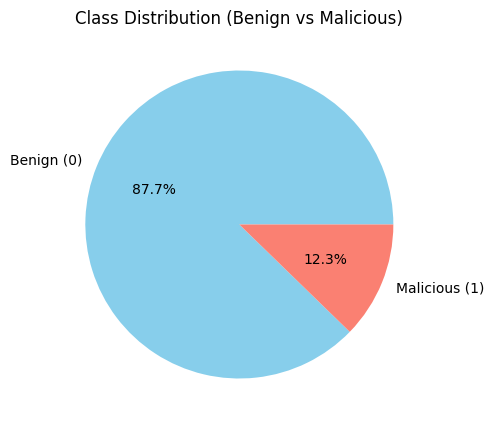

In [69]:
plt.figure(figsize=(5, 5))
plt.pie(class_counts, labels=labels, autopct='%1.1f%%', colors=["skyblue", "salmon"])
plt.title("Class Distribution (Benign vs Malicious)")
plt.show()

##### **2.7.3 Correlation Matrix between the Data**

In [70]:
df.corr()

,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,PHY_LAYER_ARRIVAL_TIME(US),PHY_LAYER_START_TIME(US),PHY_LAYER_END_TIME(US),NW_LAYER_PAYLOAD(Bytes),MAC_LAYER_PAYLOAD(Bytes),SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,PCKT_LABEL,RPL_RANK
PACKET_TYPE,1.000000,-0.881901,-0.283508,0.111195,-0.256756,-0.085897,-0.168748,-0.168748,-0.168748,0.996665,0.980556,0.229993,-0.599243,0.019292,-0.639698,-0.527382,NaN
CONTROL_PACKET_TYPE/APP_NAME,-0.881901,1.000000,0.505103,-0.224006,0.385329,0.091534,0.189369,0.189369,0.189369,-0.877360,-0.838767,-0.291746,0.588592,-0.087934,0.633348,0.573962,-0.823017
SOURCE_ID,-0.283508,0.505103,1.000000,-0.556670,0.848596,0.026462,0.222365,0.222365,0.222365,-0.284863,-0.180045,-0.444035,0.452620,-0.352939,0.469023,0.624437,-0.594385
DESTINATION_ID,0.111195,-0.224006,-0.556670,1.000000,-0.509160,0.069758,-0.258347,-0.258347,-0.258347,0.110514,-0.050878,0.376301,-0.574783,0.376297,-0.556868,-0.768823,0.615421
TRANSMITTER_ID,-0.256756,0.385329,0.848596,-0.509160,1.000000,0.022883,0.204679,0.204679,0.204679,-0.258048,-0.160293,-0.407886,0.425633,-0.305038,0.439416,0.578912,-0.594385
RECEIVER_ID,-0.085897,0.091534,0.026462,0.069758,0.022883,1.000000,0.033377,0.033377,0.033377,-0.085980,-0.074212,-0.137498,0.154114,-0.062569,0.162028,0.094665,-0.124772
PHY_LAYER_ARRIVAL_TIME(US),-0.168748,0.189369,0.222365,-0.258347,0.204679,0.033377,1.000000,1.000000,1.000000,-0.169766,-0.115179,-0.225534,0.269531,-0.184231,0.269620,0.350642,-0.274432
PHY_LAYER_START_TIME(US),-0.168748,0.189369,0.222365,-0.258347,0.204679,0.033377,1.000000,1.000000,1.000000,-0.169766,-0.115179,-0.225534,0.269531,-0.184231,0.269620,0.350642,-0.274432
PHY_LAYER_END_TIME(US),-0.168748,0.189369,0.222365,-0.258347,0.204679,0.033377,1.000000,1.000000,1.000000,-0.169766,-0.115179,-0.225534,0.269532,-0.184231,0.269621,0.350642,-0.274432
NW_LAYER_PAYLOAD(Bytes),0.996665,-0.877360,-0.284863,0.110514,-0.258048,-0.085980,-0.169766,-0.169766,-0.169766,1.000000,0.982666,0.225184,-0.605100,0.015284,-0.645712,-0.529838,NaN


##### **2.7.4 Correlation Heatmap the Data**

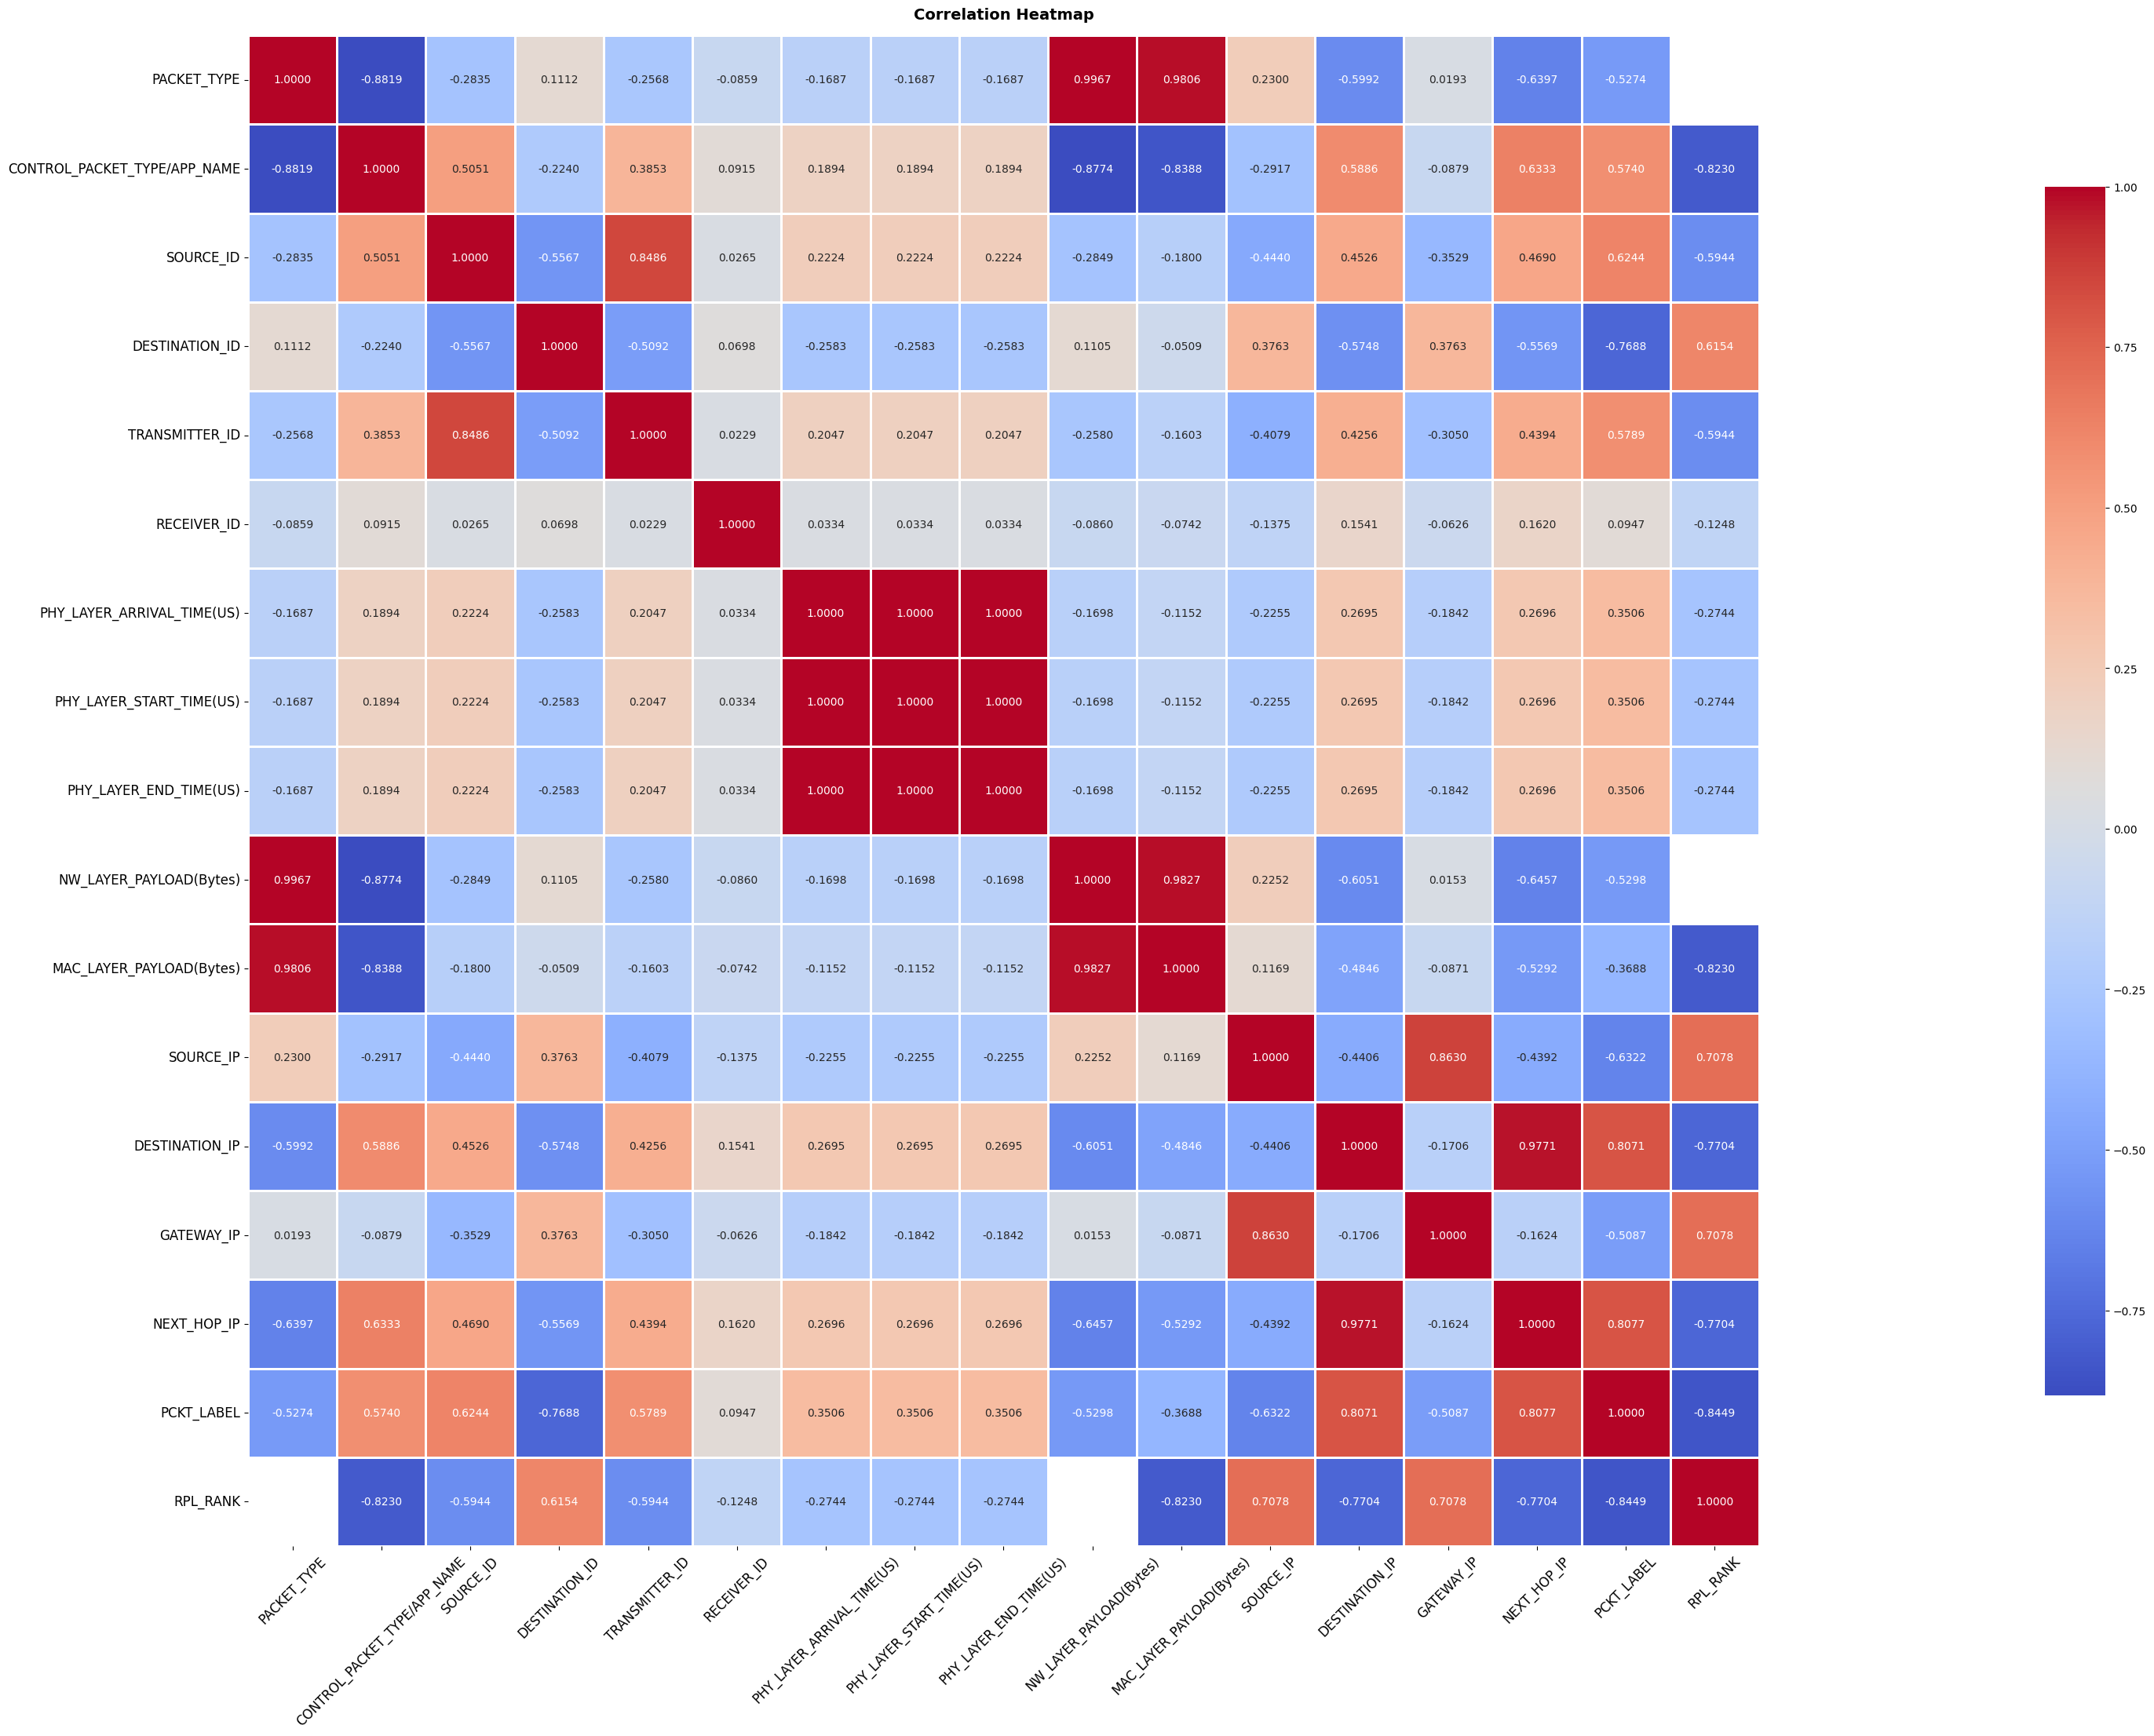

In [71]:
# Visualize correlation between features using a heatmap
# Check correlation and plot heatmap
plt.figure(figsize=(94, 25))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".4f", linewidths=2, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.show()

#### **2.8 Feature Engineering**

##### **2.8.1 Feature Scaling using StandardScaler**

In [72]:
# Exclude label column from scaling (Separate features and target variable)
X = df.drop(columns=["PCKT_LABEL"]) # Features
y = df["PCKT_LABEL"]                # Target

# Apply StandardScaler
scaler = StandardScaler()           # Initialize the scaler
X_scaled = scaler.fit_transform(X)  # Apply scaling to features

# Convert back to DataFrame (for column reference)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)  # Convert the scaled data back to DataFrame for easy viewing

# Print the scaled features
console.print(f"[bold green]Feature scaling completed using StandardScaler.[/bold green]")
console.print(f"[bold blue]Scaled Data Shape:[/bold blue] {X_scaled_df.shape}")

Feature scaling completed using StandardScaler.

Scaled Data Shape: (897680, 16)

In [73]:
console.print(f"[bold green]Scaled Feature Values:[/bold green]")
X_scaled_df.head()

Scaled Feature Values:

,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,PHY_LAYER_ARRIVAL_TIME(US),PHY_LAYER_START_TIME(US),PHY_LAYER_END_TIME(US),NW_LAYER_PAYLOAD(Bytes),MAC_LAYER_PAYLOAD(Bytes),SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,RPL_RANK
0,-0.197267,1.201228,2.646917,-0.287577,2.470241,-1.702866,-3.364658,-3.364657,-3.364664,3.784996,2.586675,-2.483743,-5.046572,-2.382862,-5.243150,NaN
1,-0.197267,1.201228,-5.558463,-0.287577,-5.192338,1.245818,-3.364658,-3.364657,-3.364664,3.784996,2.586675,-2.933194,-5.046572,-2.821380,-5.243150,NaN
2,-0.197267,0.214690,2.646917,-0.287577,2.470241,0.378558,-3.364635,-3.364635,-3.364635,-0.198185,-0.137937,4.258027,0.301890,4.194906,0.302132,-3.166823
3,-0.197267,0.214690,2.646917,-0.287577,2.470241,0.898914,-3.364635,-3.364635,-3.364635,-0.198185,-0.137937,4.258027,0.301890,4.194906,0.302132,-3.166823
4,-0.197267,0.214690,2.646917,-0.287577,2.470241,-1.355962,-3.364635,-3.364635,-3.364635,-0.198185,-0.137937,4.258027,0.301890,4.194906,0.302132,-3.166823


### **3. Model Building, Implementation and Evaluation**

#### **3.1 Imputing NaN Values**

In [74]:
# Impute remaining NaNs with column means (recommended for numeric features)
X_scaled_df.fillna(X_scaled_df.mean(), inplace=True)

console.print("[bold green]NaN values filled using column mean.[/bold green]")
console.print(f"[bold blue]New shape after imputation:[/bold blue] {X_scaled_df.shape}")

NaN values filled using column mean.

New shape after imputation: (897680, 16)

#### **3.2 Applying SMOTE to Entire Dataset (Before Splitting)**

In [75]:
# Apply SMOTE to the entire dataset
sm = SMOTE(random_state=42)
X_smote, y_smote = sm.fit_resample(X_scaled_df, y)

# Shuffle the resampled data
X_smote, y_smote = shuffle(X_smote, y_smote, random_state=42)

console.print("[bold green]Class distribution after applying SMOTE to full dataset:[/bold green]")
console.print(y_smote.value_counts())

Class distribution after applying SMOTE to full dataset:

PCKT_LABEL
0    787499
1    787499
Name: count, dtype: int64

#### **3.3 Data Splitting using Test-Train Split**

In [76]:
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.3, random_state=42, stratify=y_smote)

console.print("[bold green]Train-test split completed.[/bold green]")
console.print(f"[bold blue]Training Set:[/bold blue] {X_train.shape[0]} samples",
              f"\n[bold blue]Testing Set :[/bold blue] {X_test.shape[0]} samples")

Train-test split completed.

Training Set: 1102498 samples 
Testing Set : 472500 samples

#### **3.4 Helper Function for Model Evaluation**

In [77]:
# Helper to evaluate model
def evaluate_model(model, model_name, X_test, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    console.print(f"[bold]{model_name} Evaluation (SMOTE Before Split)[/bold]",
                  f"\n[bold]Accuracy :[/bold] {acc:.4f}",
                  f"\n[bold]Precision:[/bold] {prec:.4f}",
                  f"\n[bold]Recall   :[/bold] {rec:.4f}",
                  f"\n[bold]F1 Score :[/bold] {f1:.4f}")

    # Confusion Matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # First 10 predictions    
    sample_idx = np.random.choice(len(y_test), size=10, replace=False)
    comparison_df = pd.DataFrame({
        'Actual': y_test.values[sample_idx],
        'Predicted': y_pred[sample_idx]
    })
    console.print(f"[bold]Random 10 Predictions - {model_name}[/bold]")
    console.print(comparison_df)

#### **3.5 Model Implementation**

##### **3.5.1 Linear Regression**

Logistic Regression (SMOTE Before Split) Evaluation (SMOTE Before Split) 
Accuracy : 0.9995 
Precision: 0.9989 
Recall   : 1.0000 
F1 Score : 0.9995

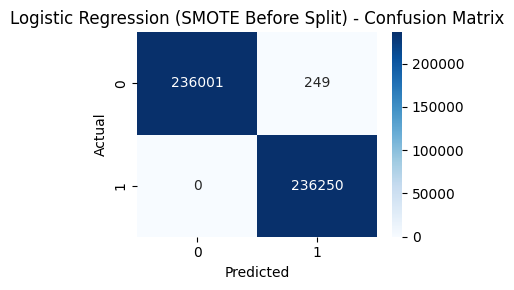

Random 10 Predictions - Logistic Regression (SMOTE Before Split)

Actual  Predicted
0       0          0
1       1          1
2       0          0
3       0          0
4       0          0
5       0          0
6       1          1
7       1          1
8       1          1
9       0          0

In [78]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

evaluate_model(lr_model,"Logistic Regression (SMOTE Before Split)",X_test, y_test,y_pred_lr)

##### **3.5.2 Random Forest**

Random Forest Classifier (SMOTE Before Split) Evaluation (SMOTE Before Split) 
Accuracy : 1.0000 
Precision: 1.0000 
Recall   : 1.0000 
F1 Score : 1.0000

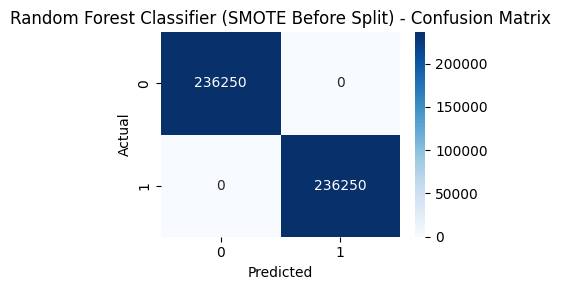

Random 10 Predictions - Random Forest Classifier (SMOTE Before Split)

Actual  Predicted
0       0          0
1       1          1
2       0          0
3       0          0
4       1          1
5       0          0
6       0          0
7       0          0
8       1          1
9       0          0

In [79]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

evaluate_model(rf_model,"Random Forest Classifier (SMOTE Before Split)",X_test, y_test,y_pred_rf)

##### **3.5.3 MLP (Neural Network)**

Neural Network - MLP (SMOTE Before Split) Evaluation (SMOTE Before Split) 
Accuracy : 0.9999 
Precision: 0.9999 
Recall   : 1.0000 
F1 Score : 0.9999

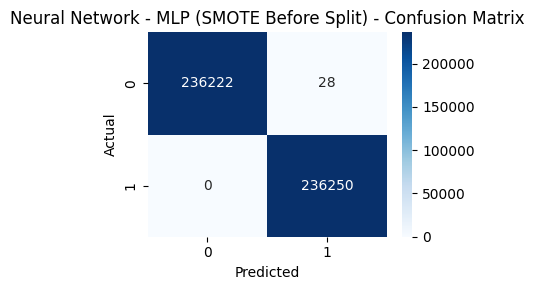

Random 10 Predictions - Neural Network - MLP (SMOTE Before Split)

Actual  Predicted
0       0          0
1       0          0
2       1          1
3       1          1
4       0          0
5       0          0
6       0          0
7       0          0
8       1          1
9       1          1

In [80]:
# Multi-layer Perceptron (Neural Net)
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=300, random_state=42)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

evaluate_model(mlp_model,"Neural Network - MLP (SMOTE Before Split)",X_test, y_test,y_pred_mlp)

##### **3.5.4 LSTM (Long-Short Term Memory)**

In [81]:
# ============================================================================================================
# Step 1: Prepare Sequential Data
# ============================================================================================================
def create_lstm_sequences(X, y, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size].values)
        y_seq.append(y[i+window_size])
    return np.array(X_seq), np.array(y_seq)

X_lstm, y_lstm = create_lstm_sequences(X_scaled_df, y, window_size=10)

X_tensor = torch.tensor(X_lstm, dtype=torch.float32)
y_tensor = torch.tensor(y_lstm, dtype=torch.float32)

In [82]:
# ============================================================================================================
# Step 2: Train-Test Split for Sequences
# ============================================================================================================

# Split into 70% train / 30% test
train_size = int(0.7 * len(X_tensor))
test_size = len(X_tensor) - train_size

train_dataset, test_dataset = random_split(TensorDataset(X_tensor, y_tensor), [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [83]:
# ============================================================================================================
# Step 3: Define LSTM Model
# ============================================================================================================

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # take the output from the last time step
        out = self.fc(out)
        return self.sigmoid(out)

input_size = X_scaled_df.shape[1]
model = LSTMClassifier(input_size=input_size, hidden_size=64, num_layers=2)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [84]:
# ============================================================================================================
# Step 4: Train the LSTM Model
# ============================================================================================================

model.train()
epochs = 5
loss_history = []

for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_x).squeeze()
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    console.print(f"[bold green]Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}[/bold green]")

Epoch 1/5, Loss: 0.0911

Epoch 2/5, Loss: 0.0830

Epoch 3/5, Loss: 0.0812

Epoch 4/5, Loss: 0.0802

Epoch 5/5, Loss: 0.0794

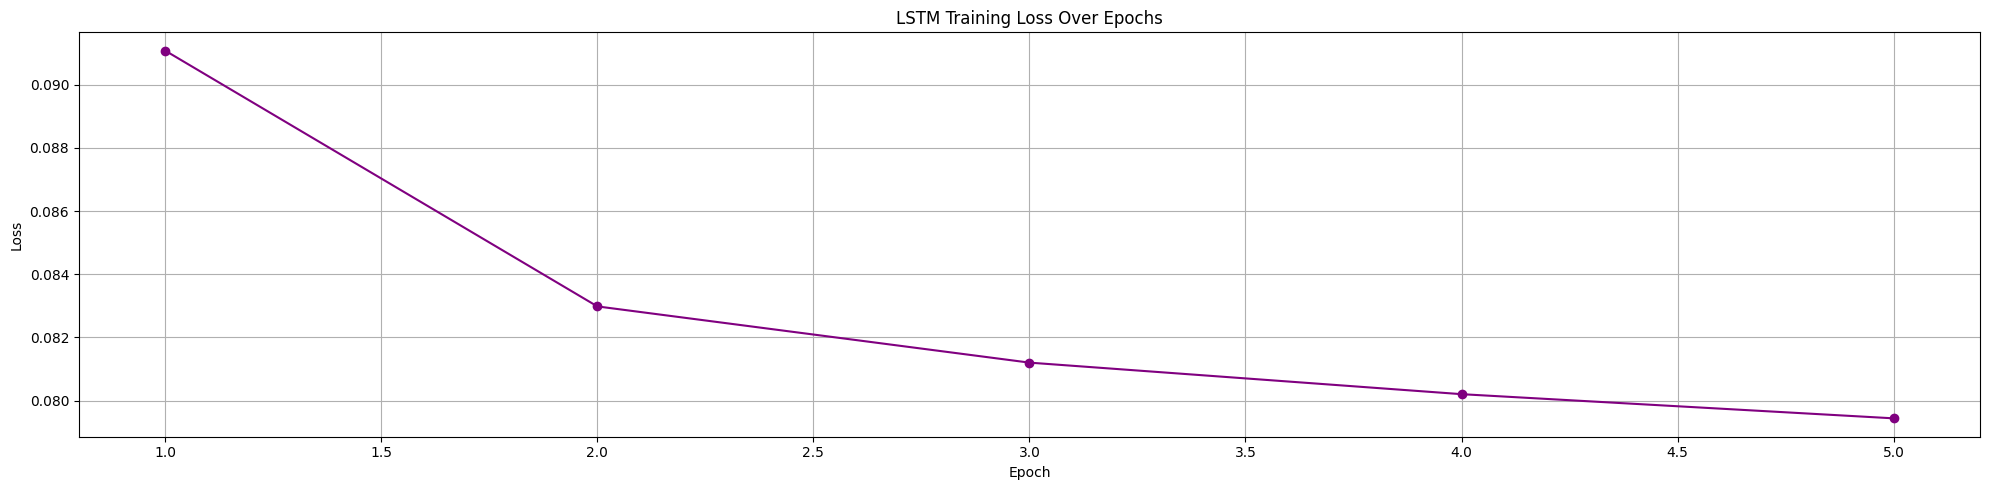

In [85]:
# ============================================================================================================
# Step 5: Plot Loss Curve
# ============================================================================================================

plt.figure(figsize=(20, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', color='purple')
plt.title("LSTM Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

LSTM (SMOTE Before Split) Evaluation (SMOTE Before Split) 
Accuracy : 0.9634 
Precision: 0.9770 
Recall   : 0.9814 
F1 Score : 0.9792

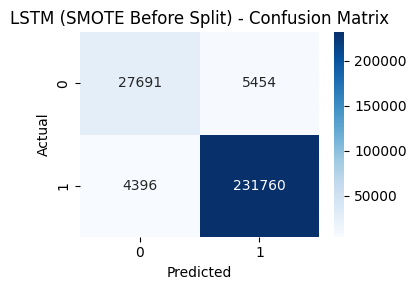

Random 10 Predictions - LSTM (SMOTE Before Split)

Actual  Predicted
248249       1          1
39581        1          1
230172       1          1
69677        1          1
85940        1          1
132485       1          1
86023        1          1
196923       0          1
63633        1          1
47766        1          1

In [86]:
# ============================================================================================================
# Step 6: Evaluate the LSTM Model
# ============================================================================================================

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        output = model(batch_x).squeeze()
        preds = (output > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

y_pred_series = pd.Series(np.array(all_preds).astype(int))
y_test_series = pd.Series(np.array(all_labels).astype(int))

evaluate_model(model=None, model_name="LSTM (SMOTE Before Split)",
               X_test=None, y_test=y_test_series, y_pred=y_pred_series)

##### **3.5.5 GRU (Gated Recurrent Units)**

In [87]:
# ============================================================================================================
# Step 1: Prepare Sequential Data Apply Train-Test Split
# ============================================================================================================

def create_gru_sequences(X, y, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size].values)
        y_seq.append(y[i+window_size])
    return np.array(X_seq), np.array(y_seq)

X_gru, y_gru = create_gru_sequences(X_scaled_df, y, window_size=10)

X_tensor_gru = torch.tensor(X_gru, dtype=torch.float32)
y_tensor_gru = torch.tensor(y_gru, dtype=torch.float32)

In [88]:
# ============================================================================================================
# Step 2: Apply Train-Test Split
# ============================================================================================================

train_size = int(0.7 * len(X_tensor_gru))
test_size = len(X_tensor_gru) - train_size

train_dataset_gru, test_dataset_gru = random_split(TensorDataset(X_tensor_gru, y_tensor_gru), [train_size, test_size])
train_loader_gru = DataLoader(train_dataset_gru, batch_size=64, shuffle=True)
test_loader_gru = DataLoader(test_dataset_gru, batch_size=64)

In [89]:
# ============================================================================================================
# Step 3: Define the GRU Model
# ============================================================================================================

class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(GRUClassifier, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return self.sigmoid(out)

input_size = X_scaled_df.shape[1]
gru_model = GRUClassifier(input_size=input_size, hidden_size=64, num_layers=2)

criterion_gru = nn.BCELoss()
optimizer_gru = torch.optim.Adam(gru_model.parameters(), lr=0.001)

In [90]:
# ============================================================================================================
# Step 4: Train GRU Model
# ============================================================================================================

gru_model.train()
epochs = 5
gru_loss_history = []

for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, batch_y in train_loader_gru:
        optimizer_gru.zero_grad()
        output = gru_model(batch_x).squeeze()
        loss = criterion_gru(output, batch_y)
        loss.backward()
        optimizer_gru.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_gru)
    gru_loss_history.append(avg_loss)
    console.print(f"[bold green]GRU Epoch {epoch+1}/{epochs}, GRU Loss: {avg_loss:.4f}[/bold green]")

GRU Epoch 1/5, GRU Loss: 0.0902

GRU Epoch 2/5, GRU Loss: 0.0831

GRU Epoch 3/5, GRU Loss: 0.0818

GRU Epoch 4/5, GRU Loss: 0.0809

GRU Epoch 5/5, GRU Loss: 0.0803

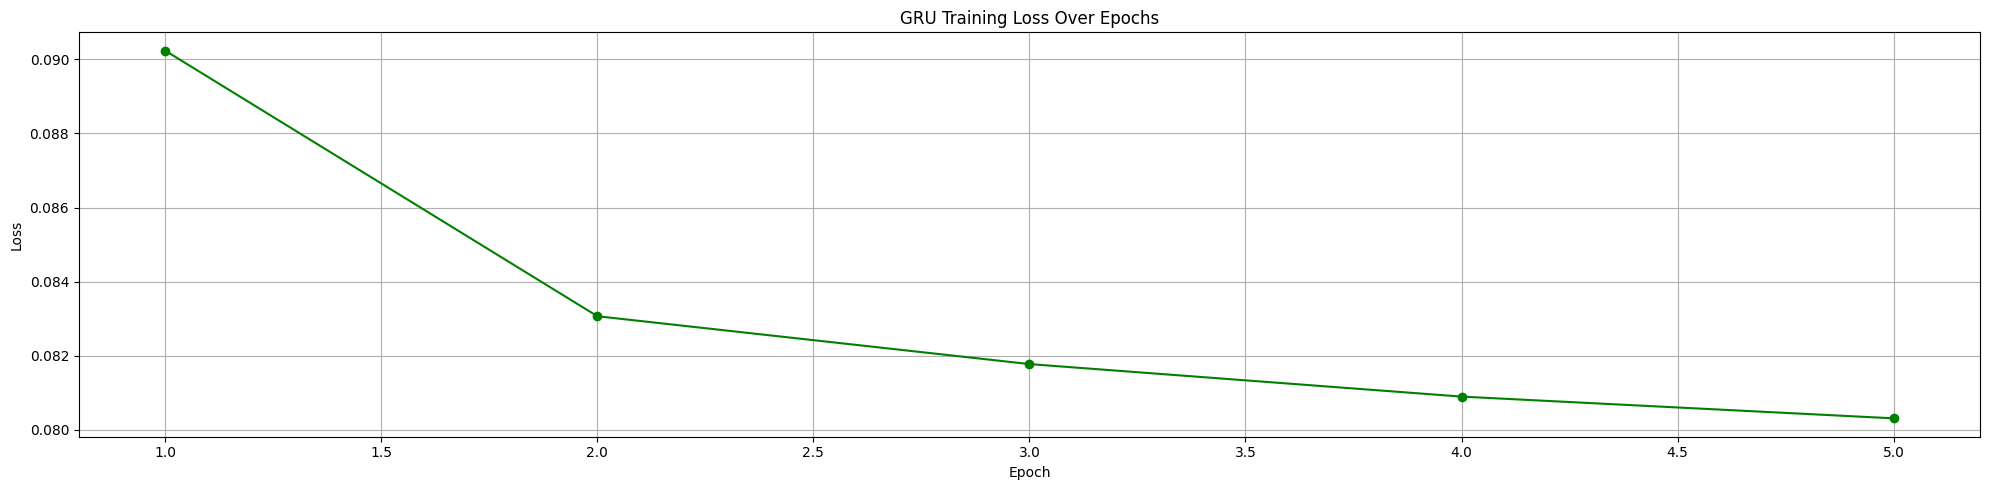

In [91]:
# ============================================================================================================
# Step 5: Plot Training Loss
# ============================================================================================================

plt.figure(figsize=(20, 5))
plt.plot(range(1, epochs + 1), gru_loss_history, marker='o', linestyle='-', color='green')
plt.title("GRU Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

GRU (SMOTE Before Split) Evaluation (SMOTE Before Split) 
Accuracy : 0.9640 
Precision: 0.9796 
Recall   : 0.9794 
F1 Score : 0.9795

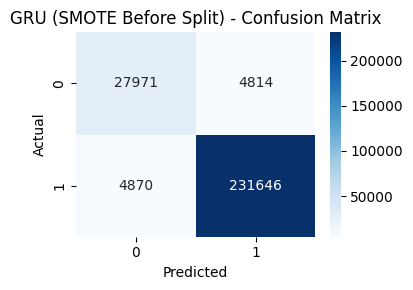

Random 10 Predictions - GRU (SMOTE Before Split)

Actual  Predicted
203562       1          1
89354        0          0
173732       1          1
53954        1          1
137877       1          1
110964       1          1
214391       1          1
69450        1          1
45925        1          1
19728        1          1

In [92]:
# ============================================================================================================
# Step 6: Evaluate GRU Model
# ============================================================================================================

gru_model.eval()
all_preds_gru, all_labels_gru = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader_gru:
        output = gru_model(batch_x).squeeze()
        preds = (output > 0.5).float()
        all_preds_gru.extend(preds.cpu().numpy())
        all_labels_gru.extend(batch_y.cpu().numpy())

y_pred_gru = pd.Series(np.array(all_preds_gru).astype(int))
y_test_gru = pd.Series(np.array(all_labels_gru).astype(int))

evaluate_model(model=None, model_name="GRU (SMOTE Before Split)",
               X_test=None, y_test=y_test_gru, y_pred=y_pred_gru)

##### **3.5.6 Isolation Forest**

In [93]:
# ============================================================================================================
# Step 1: Filter benign samples for training
# ============================================================================================================

X_benign = X_scaled_df[y == 0]
X_full = X_scaled_df
y_true = y.reset_index(drop=True)

In [94]:
# ============================================================================================================
# Step 2: Fit Isolation Forest on benign data only
# ============================================================================================================

iso_model = IsolationForest(n_estimators=100, contamination="auto", random_state=42)
iso_model.fit(X_benign)

IsolationForest(random_state=42)

In [95]:
# ============================================================================================================
# Step 3: Predict on full dataset
# ============================================================================================================

predictions = iso_model.predict(X_full)
# IsolationForest outputs: 1 = normal, -1 = anomaly → convert to: 0 = benign, 1 = attack
y_pred_iso = pd.Series((predictions == -1).astype(int))

Isolation Forest (Benign Only Training) Evaluation (SMOTE Before Split) 
Accuracy : 0.9288 
Precision: 0.9250 
Recall   : 1.0000 
F1 Score : 0.9610

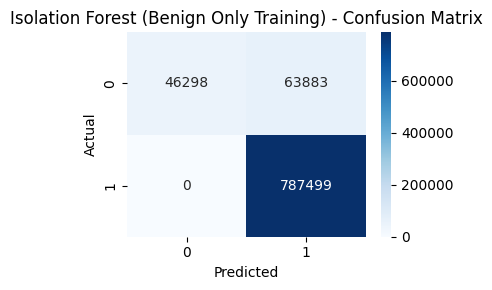

Random 10 Predictions - Isolation Forest (Benign Only Training)

Actual  Predicted
365671       1          1
257245       1          1
738027       1          1
502527       1          1
393534       1          1
104894       1          1
801684       1          1
716873       1          1
250145       1          1
38882        0          1

In [96]:
# ============================================================================================================
# Step 4: Evaluate Isolation Forest Model
# ============================================================================================================

evaluate_model(model=None, model_name="Isolation Forest (Benign Only Training)", X_test=None, y_test=y_true, y_pred=y_pred_iso)

### **4. Model Performance Comparison**

#### **4.1 Tabular Summary of All Metrics**

In [97]:
# Add Isolation Forest metrics to comparison dictionary
metrics = {
    "Logistic Regression":  [accuracy_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr),
                             recall_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr)],
    
    "Random Forest":        [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
                             recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf)],
    
    "MLP Neural Net":       [accuracy_score(y_test, y_pred_mlp), precision_score(y_test, y_pred_mlp),
                             recall_score(y_test, y_pred_mlp), f1_score(y_test, y_pred_mlp)],
    
    "LSTM":                 [accuracy_score(y_test_series, y_pred_series),
                             precision_score(y_test_series, y_pred_series),
                             recall_score(y_test_series, y_pred_series),
                             f1_score(y_test_series, y_pred_series)],
    
    "GRU":                  [accuracy_score(y_test_gru, y_pred_gru),
                             precision_score(y_test_gru, y_pred_gru),
                             recall_score(y_test_gru, y_pred_gru),
                             f1_score(y_test_gru, y_pred_gru)],
    
    "Isolation Forest":     [accuracy_score(y_true, y_pred_iso),
                             precision_score(y_true, y_pred_iso),
                             recall_score(y_true, y_pred_iso),
                             f1_score(y_true, y_pred_iso)]
}

comparison_df = pd.DataFrame(metrics, index=["Accuracy", "Precision", "Recall", "F1 Score"]).T.round(4)

console.print("[bold green]Model Performance Comparison (SMOTE Before Split)[/bold green]")
console.print(comparison_df)

Model Performance Comparison (SMOTE Before Split)

Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.9995     0.9989  1.0000    0.9995
Random Forest          1.0000     1.0000  1.0000    1.0000
MLP Neural Net         0.9999     0.9999  1.0000    0.9999
LSTM                   0.9634     0.9770  0.9814    0.9792
GRU                    0.9640     0.9796  0.9794    0.9795
Isolation Forest       0.9288     0.9250  1.0000    0.9610

#### **4.2 Barplot for All Metrics**

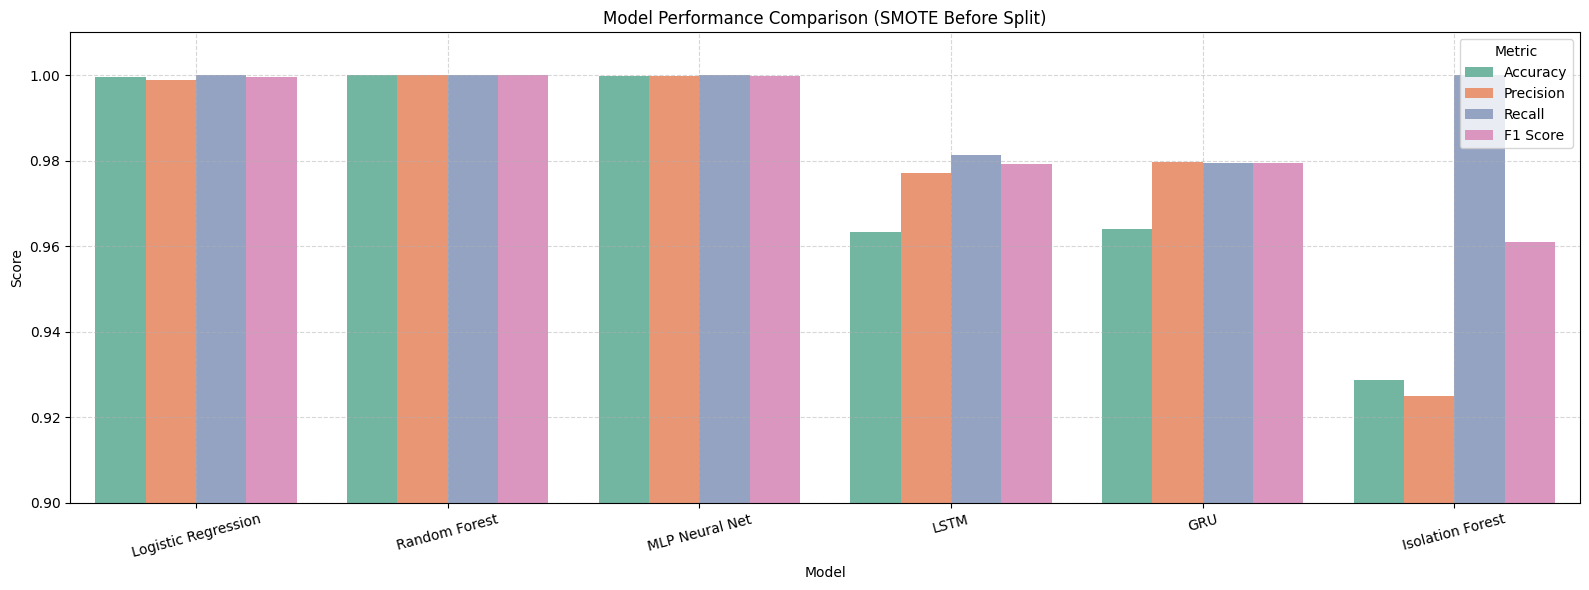

In [98]:
melted_df = comparison_df.reset_index().melt(id_vars="index", var_name="Metric", value_name="Score")
melted_df.rename(columns={"index": "Model"}, inplace=True)

plt.figure(figsize=(16, 6))
sns.barplot(data=melted_df, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Model Performance Comparison (SMOTE Before Split)")
plt.ylabel("Score")
plt.ylim(0.90, 1.01)
plt.xticks(rotation=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### **4.3 Slope Graph for F1 Score**

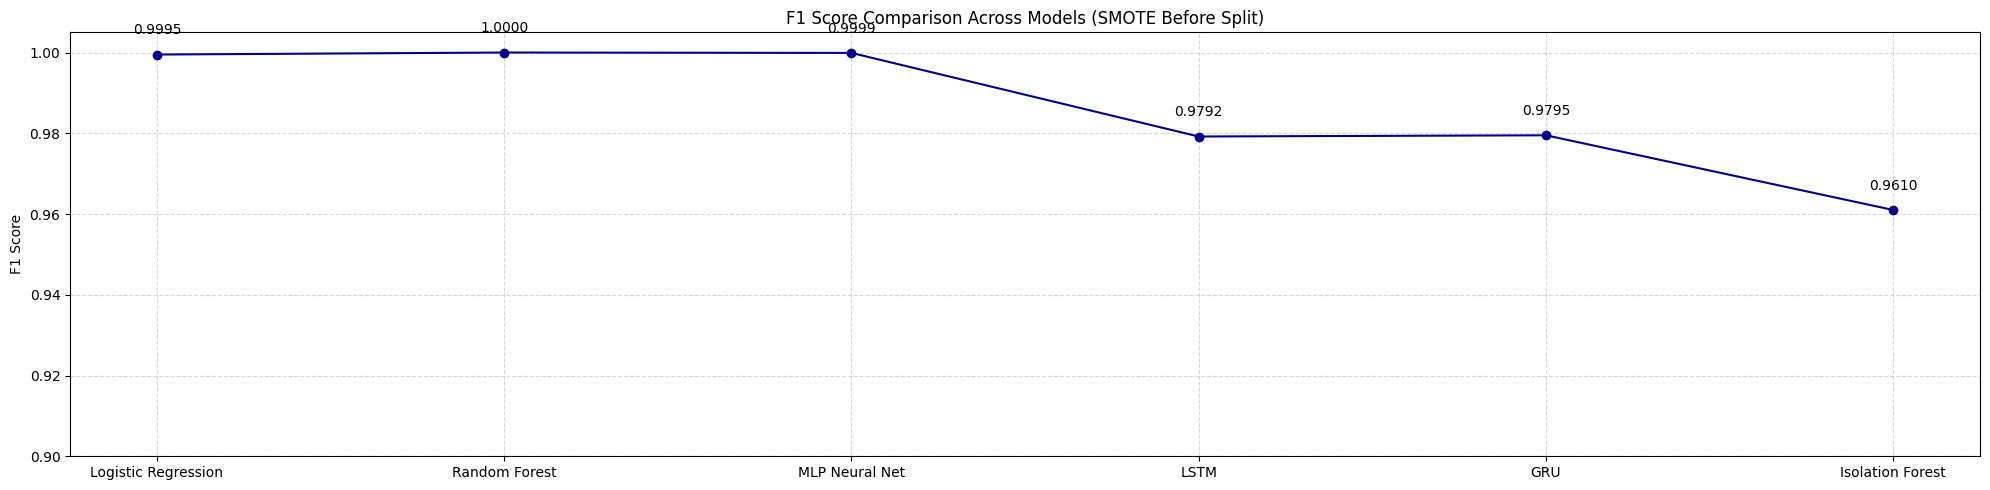

In [99]:
plt.figure(figsize=(20, 5))
plt.plot(comparison_df.index, comparison_df["F1 Score"], marker='o', linestyle='-', color='darkblue')

for i, score in enumerate(comparison_df["F1 Score"]):
    plt.text(i, score + 0.005, f"{score:.4f}", ha='center')

plt.title("F1 Score Comparison Across Models (SMOTE Before Split)")
plt.ylabel("F1 Score")
plt.ylim(0.90, 1.005)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **5. Exporting Results**

#### **5.1 Model metrics for LR, RF, MLP, LSTM, GRU and Isolation Model**

In [100]:
comparison_df.to_csv("6_results_notebook3.csv") 

#### **5.2 Confusion Matrices**

In [101]:
confusion_dict = {
    "LR": confusion_matrix(y_test, y_pred_lr),
    "RF": confusion_matrix(y_test, y_pred_rf),
    "MLP": confusion_matrix(y_test, y_pred_mlp),
    "LSTM": confusion_matrix(y_test_series, y_pred_series),
    "GRU": confusion_matrix(y_test_gru, y_pred_gru),
    "ISO": confusion_matrix(y_true, y_pred_iso)
}

with open("7_confusion_notebook3.pkl", "wb") as f:
    pickle.dump(confusion_dict, f)